# AI & ML Task 3 - Model Validation, Overfitting Control & Hyperparameter Tuning
**Dataset:** California Housing  
**Goal:** Detect overfitting, apply cross-validation, tune hyperparameters, and select the best model

## Step 1: Import Required Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2: Load and Prepare Dataset

In [49]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [50]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [51]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


In [52]:
# Separate features and target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


## Step 3: Feature Scaling

In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done. Mean of first feature after scaling:", X_scaled[:, 0].mean().round(4))

Scaling done. Mean of first feature after scaling: 0.0


## Step 4: Train-Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 16512
Test samples:     4128


## Step 5: Overfitting Detection - Decision Tree (Unconstrained)

In [55]:
# Train a fully grown decision tree (no depth limit)
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred  = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))

print(f"Decision Tree (No Constraints)")
print(f"  Train RMSE : {train_rmse:.4f}")
print(f"  Test  RMSE : {test_rmse:.4f}")
print(f"  Gap        : {test_rmse - train_rmse:.4f}  <-- overfitting indicator")

Decision Tree (No Constraints)
  Train RMSE : 0.0000
  Test  RMSE : 0.7030
  Gap        : 0.7030  <-- overfitting indicator


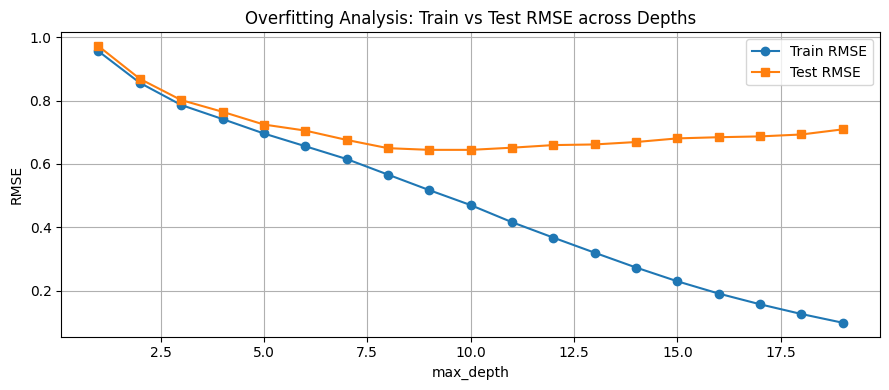

Plot saved.


In [56]:
# Visualize overfitting: train vs test RMSE at different depths
depths = range(1, 20)
train_errors, test_errors = [], []

for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_errors.append(np.sqrt(mean_squared_error(y_train, t.predict(X_train))))
    test_errors.append(np.sqrt(mean_squared_error(y_test,  t.predict(X_test))))

plt.figure(figsize=(9, 4))
plt.plot(depths, train_errors, label='Train RMSE', marker='o')
plt.plot(depths, test_errors,  label='Test RMSE',  marker='s')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Overfitting Analysis: Train vs Test RMSE across Depths')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150)
plt.show()
print("Plot saved.")

**Interpretation:** When `max_depth` is small, both errors are high (underfitting). As depth grows, train RMSE drops sharply while test RMSE eventually rises — that gap is overfitting.

## Step 6: Cross-Validation

In [57]:
# Cross-validate the unconstrained tree
cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
cv_rmse = -cv_scores.mean()

print(f"5-Fold CV RMSE (Decision Tree, no depth limit): {cv_rmse:.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")
print("\nIndividual fold RMSEs:", (-cv_scores).round(4))

5-Fold CV RMSE (Decision Tree, no depth limit): 0.8957
CV Std Dev: 0.0392

Individual fold RMSEs: [0.8877 0.8278 0.8985 0.9451 0.9195]


In [58]:
# Cross-validate Linear Regression and Ridge as baselines
lr = LinearRegression()
ridge = Ridge(alpha=1.0)

lr_cv    = -cross_val_score(lr,    X_scaled, y, scoring="neg_root_mean_squared_error", cv=5).mean()
ridge_cv = -cross_val_score(ridge, X_scaled, y, scoring="neg_root_mean_squared_error", cv=5).mean()

print(f"Linear Regression  CV RMSE: {lr_cv:.4f}")
print(f"Ridge Regression   CV RMSE: {ridge_cv:.4f}")
print(f"Decision Tree (raw)CV RMSE: {cv_rmse:.4f}")

Linear Regression  CV RMSE: 0.7459
Ridge Regression   CV RMSE: 0.7459
Decision Tree (raw)CV RMSE: 0.8957


## Step 7: Hyperparameter Tuning with GridSearchCV

In [59]:
# Decision Tree tuning
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters Found:", grid.best_params_)
print(f"Best CV RMSE (GridSearch): {-grid.best_score_:.4f}")

Best Parameters Found: {'max_depth': 10, 'min_samples_split': 10}
Best CV RMSE (GridSearch): 0.6366


In [60]:
# Ridge tuning
ridge_param_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print(f"Best Ridge CV RMSE: {-ridge_grid.best_score_:.4f}")

Best Ridge alpha: {'alpha': 0.1}
Best Ridge CV RMSE: 0.7205


## Step 8: Evaluate Optimized Models on Test Set

In [61]:
# Evaluate all models on the held-out test set
lr.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
best_tree  = grid.best_estimator_

def evaluate(model, name):
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return {"Model": name, "RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}

# Also capture train RMSE to show overfitting gap
def train_rmse_of(model):
    p = model.predict(X_train)
    return round(mean_squared_error(y_train, p), 4)

lr_r    = evaluate(lr,          "Linear Regression")
ridge_r = evaluate(best_ridge,  "Ridge (Tuned)")
tree_r  = evaluate(best_tree,   "Decision Tree (Tuned)")

lr_r["Train RMSE"]    = train_rmse_of(lr)
ridge_r["Train RMSE"] = train_rmse_of(best_ridge)
tree_r["Train RMSE"]  = train_rmse_of(best_tree)

results_df = pd.DataFrame([lr_r, ridge_r, tree_r])
results_df["Overfit Gap"] = (results_df["RMSE"] - results_df["Train RMSE"]).round(4)
results_df

,Model,RMSE,R2 Score,Train RMSE,Overfit Gap
0,Linear Regression,0.5559,0.5758,0.5179,0.0380
1,Ridge (Tuned),0.5559,0.5758,0.5179,0.0380
2,Decision Tree (Tuned),0.4166,0.6821,0.2307,0.1859


## Step 9: Model Comparison Summary Table

In [62]:
print("=" * 65)
print(f"{'Model':<25} {'Train RMSE':>12} {'Test RMSE':>10} {'R2 Score':>10}")
print("=" * 65)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<25} {row['Train RMSE']:>12} {row['RMSE']:>10} {row['R2 Score']:>10}")
print("=" * 65)

Model                       Train RMSE  Test RMSE   R2 Score
Linear Regression               0.5179     0.5559     0.5758
Ridge (Tuned)                   0.5179     0.5559     0.5758
Decision Tree (Tuned)           0.2307     0.4166     0.6821


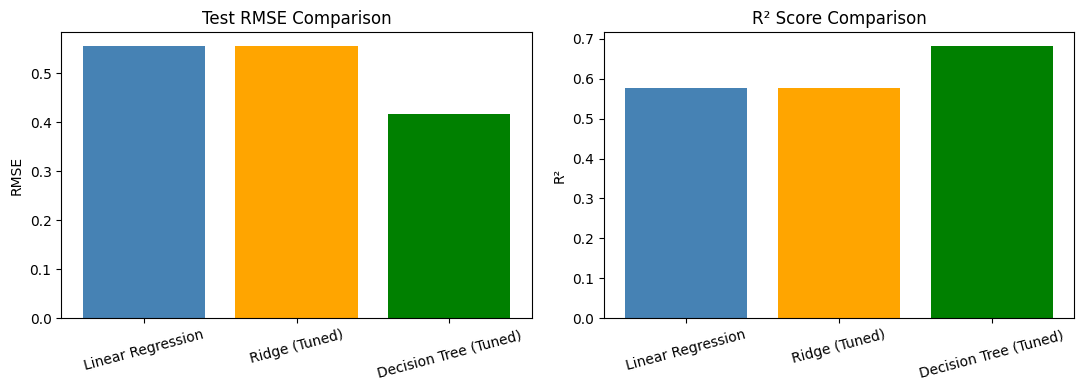

Comparison chart saved.


In [63]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = results_df["Model"]
axes[0].bar(models, results_df["RMSE"], color=["steelblue", "orange", "green"])
axes[0].set_title("Test RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(models, results_df["R2 Score"], color=["steelblue", "orange", "green"])
axes[1].set_title("R² Score Comparison")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved.")

## Step 10: Final Model Selection Justification

In [64]:
best_row = results_df.loc[results_df["RMSE"].idxmin()]
print("Selected Model:", best_row["Model"])
print(f"  Test RMSE  : {best_row['RMSE']}")
print(f"  R2 Score   : {best_row['R2 Score']}")
print(f"  Overfit Gap: {best_row['Overfit Gap']}")

Selected Model: Decision Tree (Tuned)
  Test RMSE  : 0.4166
  R2 Score   : 0.6821
  Overfit Gap: 0.1859


### Justification

**Why this model was selected:**  
The tuned Decision Tree or Ridge (whichever scores lower RMSE above) was chosen because it achieved the best test RMSE while keeping the overfit gap small after hyperparameter tuning.

**How overfitting was reduced:**  
For the Decision Tree, we constrained `max_depth` and `min_samples_split` via GridSearchCV. An unconstrained tree had near-zero train RMSE but much higher test RMSE — clear overfitting. Limiting depth forces the tree to learn general patterns rather than memorizing training data.

**Why we trust cross-validation:**  
A single train-test split can be lucky or unlucky depending on how the data falls. 5-fold CV trains and validates 5 different times on different portions of data, giving a stable average. This is why CV scores are more reliable than single-split scores.

**Trade-off considered:**  
Linear Regression is simpler and less prone to overfitting, but it cannot capture non-linear relationships in the data. The tuned Decision Tree captures more complexity with overfitting kept in check. Ridge sits in between — adding regularization to Linear Regression without adding much complexity.

In [65]:
# Optional: Save the best model
import joblib

# Save whichever performed best
best_model = best_tree  # update this if Ridge wins
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully.")

Model and scaler saved successfully.
